In [1]:
%cd ..
from experiment_control.srs_microscope.srs_microscope import *
from photonmover.instruments.Oscilloscopes.HP54750A import HP54750A
from photonmover.instruments.Optical_spectrum_analyzers.HP70951B import HP70951B

# General imports
import time
import os
import numpy as np
import csv
from scipy import io
from scipy.signal import find_peaks
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
c:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:2057: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("V_{srs} $(\mu V)$")
c:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:2472: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage $(\mu V)$")
c:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:2474: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage $(\mu V)$")
c:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:2477: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_ylabel("Voltage $(\mu V)$")


c:\Users\euyehara\experiment_control


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\cffi\cparser.py:436: UserWarning: #pragma in cdef() are entirely ignored. They should be removed for now, otherwise your code might behave differently in a future version of CFFI if #pragma support gets added. Note that '#pragma pack' needs to be replaced with the 'packed' keyword argument to cdef().
  warnings.warn(


Opening connnection to Keithley source meter
Opening connection to Agilent E3633A DC Power Supply
VOA initialized to 4.99 volt


In [2]:
cam.close()
center_spot()

In [22]:
import pyvisa
def test_VCSEL_sweep(wav_start, wav_stop, Δwav, detector, fname, sample_dir, wavvolt_file=wavvolt_file, delayvolt_file=delayvolt_file, tosc_sleep=1*u.s):
    if detector == "osc":
        det = HP54750A()
    elif detector == "osa":
        det = HP70951B()
    
    t_peak = []
    det.initialize()
    
    # Create array of valid wavelengths
    wavelength_set = generate_valid_sweep(wav_start, wav_stop, Δwav, wavvolt_file=wavvolt_file)
    # Rearrange wavelength_set by increasing voltage
    daq_HVset, VOA_Vset, HVA_Vset, wavelength_set = parse_wav_delay(wavelength_set, wavvolt_file, delayvolt_file)

    # Initialize data arrays
    if isinstance(det, HP54750A):
        # Read trace from sampling oscilloscope
        [t, _] = det.read_waveform([1])
        trace_len = np.array(t).shape[1]
        trace_array = np.array(np.zeros((len(wavelength_set), int(trace_len))))
        x_axis = np.array(t[0]) * u.s
        t_sleep = tosc_sleep.to(u.s).m
    elif isinstance(det, HP70951B):
        [wavelength, _] = det.read_data()
        trace_len = np.array(wavelength).shape[0]
        trace_array = np.array(np.zeros((len(wavelength_set), int(trace_len))))
        x_axis = np.array(wavelength) * u.m
        t_sleep = 0
  
    for ind, wavelength in enumerate(wavelength_set):
        print(f"Setting to {wavelength}")
        ramp_VCSEL(wavelength)

        # Wait for trace to settle [s]
        time.sleep(t_sleep)

        #Read osc trace and store in wavelength_array
        if isinstance(det, HP54750A):
            # Read trace from sampling oscilloscope
            [_, waveform] = det.read_waveform([1])
            trace_array[ind, :] = np.reshape(np.array(waveform), (1, int(trace_len))) * u.V

        elif isinstance(det, HP70951B):
            [_, waveform] = det.read_data()
            trace_array[ind, :] = np.reshape(np.array(waveform), (1, int(trace_len)))

        #Add code to measure distance between first two peaks
        win_len = 15
        poly_order = 3
        smooth_waveform = savgol_filter(np.array(waveform), win_len, poly_order)
        pk_ind = np.argmax(smooth_waveform)

        t_peak.append(np.array(x_axis.m)[pk_ind])

    
    # Specify location of data save
    sample_dir = resolve_sample_dir(sample_dir, data_dir=data_dir)
    fpath = new_path(name=fname, data_dir=sample_dir, ds_type='testSweep', extension='h5', timestamp=True)
    print("saving data to: ")
    print(fpath)
    dump_hdf5(
    {
    'voltage_list': HVA_Vset,
    'wavelength_set': wavelength_set,
    'x_axis': x_axis,
    'trace_aray': trace_array
    },
    fpath,
    open_mode='x',
    
    )
        
    # CLOSE INSTRUMENTS
    det.close()
    
    return [wavelength_set, t_peak]


def find_peak_delay(ds0, sgolay_winlen, sgolay_polyord):
    smoothed = np.zeros(ds0['trace_aray'].shape)
    pks_val = []
    pks_loc = []

    #shift to center at first peak
    pk0_i = np.argmax(ds0['trace_aray'][0,:])
    time = ds0['x_axis'] - ds0['x_axis'][pk0_i]
    for ind in range(ds0['trace_aray'].shape[0]):
        smoothed[ind, :] = savgol_filter(ds0['trace_aray'][ind,:], window_length=sgolay_winlen, polyorder=sgolay_polyord)
        Mind = np.argmax(smoothed[ind,:])
        pks_val.append(smoothed[ind, Mind])
        pks_loc.append(time[Mind].m) 
    pks_loc = np.array(pks_loc)*u.s
    pks_norm = pks_val/ np.max(pks_val)
    fig,ax0 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
    ax0.plot(time.to(u.ps), smoothed.T)
    ax0.scatter(pks_loc.to(u.ps), pks_val, marker='x', color='r')
    ax0.set_xlabel("Time [ps]")
    ax0.set_ylabel("Voltage [V]")
    
    return pks_val, pks_loc, pks_norm


def plot_daqsweep_wavmon(ds, ds_type='sweep', colors=None, ax=None, fig=None, figsize=(6,4), normalize=False, num_reps=None, peaks_rep=None):
    """
    ds_type: 'sweep': single point daq sweeps, 'hs_im': hyperspectral image
    """
    #Load FFP peaks from calibration file
    fpath = os.path.join(calib_dir,'FFP-I_peaks')
    FFP_cal_pks = load_hdf5(fpath=fpath)
    cal_pks = FFP_cal_pks["peaks"]
    
    
    #restrict FFP_cal_pks to tuning range
    FFP_cal = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks <= np.nanmax(ds['wavelength_set']))] 
    FFP_cal = FFP_cal[~((FFP_cal > ds['wavelength_set'][0]) & (FFP_cal < ds['wavelength_set'][-1]))]

    if ds_type == 'sweep':
        wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
        wavset_sort = wavset_sort * u.nm
        wavmon_arr = ds["VCSEL_wavmon_arr"][:, s_ind]
    elif ds_type == 'hs_image':
        wavset_sort = ds["wavset_sort"]
        wavmon_arr = ds["VCSEL_wavmon_pix"]
    else:
        raise ValueError("Specify ds_type='hs_image' or 'sweep'")
    
    if num_reps is None:
        num_reps = wavmon_arr.shape[0]
    ylabel = "Volts (V)"
    if normalize:
        for row in range(num_reps):
            # remove voltage offset
            wavmon_arr[row,:] = wavmon_arr[row,:] - np.min(wavmon_arr[row])
            # normalize to max
            wavmon_arr[row,:] = wavmon_arr[row,:] / np.max(wavmon_arr[row].m)
            ylabel = "Normalized"
            
    #Find peaks
    if peaks_rep is None:
        peaks_rep = 0
    FFP_pks_ind, _ = find_peaks(wavmon_arr[peaks_rep,:], prominence=0.1, height=0.4, distance=10)
    wavmon_pks = wavmon_arr[peaks_rep, FFP_pks_ind]

    #Plotting  
    if colors is None:
        colors = cm.get_cmap("inferno", num_reps)
    
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=figsize, tight_layout=True)
    print(num_reps)
    for row in range(num_reps):
        if row %2 != 0:
            # ax.plot(wavset_sort, wavmon_arr[row], color=odd_color)
            ax.plot(wavset_sort, wavmon_arr[row], color=colors(row))
        else:
            # ax.plot(wavset_sort, wavmon_arr[row], color=even_color)
            ax.plot(wavset_sort, wavmon_arr[row], color=colors(row))
    # ax.plot(wavset_sort, wavmon_arr[peaks_rep], color='g')
    # ax.plot(wavset_sort[FFP_pks_ind], wavmon_pks, 'x', color='r')
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylabel)
    for wn in FFP_cal.m:
        plt.axvline(wn, color='k', linestyle='--')
    return fig, ax

def plot_daq_sweepSpectra(ds0, savefig=False, fname=None, fpath=None, figsize=(5,6), wavvolt=wavvolt_sweepcal, wavamp_file=wavamp_file, verbose=True, fig=None, ax=None):
    #First point in sweep already removed in unwrap_sweep()
    HVA_Vset = ds0["HVA_Vset"]
    wavelength_set = ds0["wavelength_set"]
    HV_arr = ds0["HV_arr"]
    raman_shift = ds0["raman_shift"] #sorted in order of increasing voltage

    rs_sort = np.unique(raman_shift.m) / u.cm #sorted by ascending wavelength (ascending raman_shift for tuning Stokes wavelength)

    offset = 0*u.V
    Vsrs_arr = (ds0["Vsrs_arr"] / 10 + offset).to(u.V).m * ds0["sens_lia"].to(u.V)

    Vsrs_interp_arr = calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HVA_Vset, HV_arr=HV_arr, wavvolt=wavvolt, disc_tol=5)
    if wavamp_file is not None:
        Vsrs_interp_arr = correct_amplitude(wavelength_set, Vsrs_interp_arr, HVA_Vset, wavamp_file=wavamp_file)
    # VCSEL_wavmon_arr = ds0["VCSEL_wavmon_arr"]

    Vsrs_av = np.mean(Vsrs_interp_arr, axis=0)
    uncal_Vsrs_av = np.mean(Vsrs_arr, axis=0)
    
    mind = np.nanargmax(Vsrs_av)
    mind_uncal = np.nanargmax(uncal_Vsrs_av)
    
    print("Calib Peak at {:2.3f}".format(rs_sort[mind]))
    print(f"Uncal Peak at {raman_shift[mind_uncal] :2.3f}")

    if ax is None:
        if verbose:
            fig, ax = plt.subplots(3, 1, figsize=figsize, tight_layout=True)
        else:
            fig, ax = plt.subplots(1, 1, figsize=figsize, tight_layout=True)
    
    if verbose:
        for spec in range(Vsrs_arr.shape[0]):
            ax[0].plot(raman_shift, Vsrs_arr[spec].to(u.uV))
            ax[1].plot(rs_sort, Vsrs_interp_arr[spec].to(u.uV))
        
        ax[2].plot(rs_sort, Vsrs_av.to(u.uV))
        ax[2].plot(rs_sort[mind].m, Vsrs_av[mind].to(u.uV).m, 'x')
        # ax[2].plot(raman_shift, np.mean(Vsrs_arr, axis=0).to(u.uV), 'k')
        ax[0].set_ylabel("Voltage $(\mu V)$")
        ax[0].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
        ax[1].set_ylabel("Voltage $(\mu V)$")
        ax[1].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
        ax[2].set_xlabel("Raman Shift (1/cm)")
        ax[2].set_ylabel("Voltage $(\mu V)$")
        ax[2].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    else:
        ax.plot(rs_sort, Vsrs_av.to(u.uV))
        ax.set_xlabel("Raman Shift (1/cm)")
        ax.set_ylabel("Voltage $(\mu V)$")
        ax.set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    
    if savefig:
        fname=os.path.normpath(os.path.join(fpath,fname))
        plt.savefig(fname, dpi=None, facecolor=None, edgecolor=None,
            orientation='portrait', transparent=True, bbox_inches=None, pad_inches=0.5)
    return fig, ax

def correct_amplitude(wavelength_set, Vsrs_interp_arr, HVA_Vset, wavamp_file=wavamp_file):
    #Correct Vsrs_interp_arr (wavelength-corrected Vsrs_arr) for intensity variations from wavelength-dependent VCSEL power
    #wavamp_file based on FFP tap
    #wavamp_file["wavelength"], wavamp_file["amplitude_scale"]
    a = load_hdf5(wavamp_file)
    wavelength_wavamp =  a['wavelength']
    amplitude_scale = a['amplitude_scale']
    
    # Sort by increasing wavelength (wavelength_set sorted by increasing voltage)
    wavset_sort, s_ind = np.unique(wavelength_set.to(u.nm).m, return_index=True)
    wavset_sort = wavset_sort * u.nm
    
    # Map amplitude_scale to wavset_sort using wavamp_file
    wset_ampscale = np.zeros(wavset_sort.shape)
    for i, wav in enumerate(wavset_sort):
        ind = np.argmin(np.abs(wav - wavelength_wavamp))
        wset_ampscale[i] = amplitude_scale[ind]
        
    # Scale Vsrs_interp_arr (already sorted by wavelength)
    Vsrs_corr = Vsrs_interp_arr / wset_ampscale

    return Vsrs_corr

def calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HVA_Vset, HV_arr, wavvolt=wavvolt_sweepcal, disc_tol=5):
    """
    Calibrate daq VCSEL sweep using HVA monitor.  Return calibrated Vsrs_interp_arr (wavelength interpolated to original wavelength set for consistent
    Raman shifts between iterations)
    wavelength_set: sorted by increasing voltage (same as HV_set) - see parse_wav_delay()
    """
    def line(x,a,b):
        return a*x + b
    
    #sort set wavelength by increasing wavelength ------------------
    wavset_sort = np.unique(wavelength_set.m) * u.nm
    num_sweep = Vsrs_arr.shape[0] if Vsrs_arr.ndim > 1 else 1
    dwav = np.mean(np.diff(wavset_sort))
    #-----------------
    
    # Calibrate voltage to wavelength
    a = io.loadmat(wavvolt)
    wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
    volt_calib = a['volt_interp'][0]*u.V
    
    volt_disc_low = volt_calib[np.argmin(wav_calib)]
    volt_disc_hi = volt_calib[np.argmax(wav_calib)]
    
    if wavvolt==wavvolt_HVCALIB:
        print(f"Calibrating from HV mon")
        
        # Initialize arrays
        HV_filt = np.array(np.zeros(Vsrs_arr.shape))
        wav_calib_arr = np.array(np.zeros(Vsrs_arr.shape))
        wav_calib_sort = np.array(np.zeros(Vsrs_arr.shape))
        Vsrs_interp_arr = np.array(np.zeros((num_sweep, wavset_sort.shape[0])))
        Vsrs_arr_sort = np.array(np.zeros([Vsrs_arr.shape]))
        
        for spec in range(HV_arr.shape[0]):
            popt,_ = curve_fit(line,HVA_Vset.to(u.V).m,HV_arr[spec].to(u.V).m)
            HV_filt[spec] = line(HVA_Vset.m, popt[0], popt[1])
        HV_filt = HV_filt*u.V 
    
        # Find wavelengths corresponding to measured voltage 
        # fig, ax = plt.subplots(2,1)
        for sweep_iter in range(HV_filt.shape[0]):
            for wl in range(HV_filt.shape[1]):
                ind = np.nanargmin(np.abs(HV_filt[sweep_iter, wl].m - volt_calib.m))
                wav_calib_arr[sweep_iter, wl] = wav_calib[ind].m
                
            #sort extracted wavelength from HV mon by increasing wavelength
            wlsort_ind = np.argsort(wav_calib_arr[sweep_iter])
            wav_calib_sort[sweep_iter] = wav_calib_arr[sweep_iter, wlsort_ind]
            Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
            
            # Interpolate wavelength vs spectra to uniformly sample in wavelength
            Vsrs_interp_arr[sweep_iter,:] = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort[sweep_iter,:], Vsrs_arr_sort[sweep_iter,:])

            # Remove discontinuity
            if np.max(np.diff(wavset_sort[sweep_iter,:].m)) > dwav.to(u.nm).m * disc_tol:
                bad_ind = np.where(np.diff(wavset_sort[sweep_iter,:].m) > dwav.to(u.nm).m * disc_tol)# | np.diff(wav_calib_sort[sweep_iter,:]) == 0)
                bad_ind2 = np.where(np.diff(wavset_sort[sweep_iter,:].m) == 0)
                Vsrs_interp_arr[sweep_iter, bad_ind] = np.nan
                Vsrs_interp_arr[sweep_iter, bad_ind2] = np.nan
                
    elif wavvolt==wavvolt_sweepcal: #if no HV_arr (HVA mon) provided, calibrate to wavvolt_sweepcal instead
        print(f"Calibrating from wavvolt_sweepcal")
        
        # Initialize arrays
        HV_filt = np.array(np.zeros(HVA_Vset.shape))
        wav_calib_arr = np.array(np.zeros(HVA_Vset.shape))
        wav_calib_sort = np.array(np.zeros(HVA_Vset.shape))
        Vsrs_interp_arr = np.array(np.zeros((num_sweep, wavset_sort.shape[0])))
        Vsrs_arr_sort = np.array(np.zeros(Vsrs_arr.shape))
        
        for i in range(HVA_Vset.shape[0]):
            ind = np.nanargmin(np.abs(HVA_Vset[i].m - volt_calib.m))
            wav_calib_arr[i] = wav_calib[ind].m
        
        #sort extracted wavelength from HV mon by increasing wavelength
        wlsort_ind = np.argsort(wav_calib_arr)
        wav_calib_sort = wav_calib_arr[wlsort_ind]
        
        for sweep_iter in range(Vsrs_arr.shape[0]):
            Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
        
            # Interpolate wavelength vs spectra to uniformly sample in wavelength
            Vsrs_interp_arr[sweep_iter,:] = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort, Vsrs_arr_sort[sweep_iter,:])

        # Remove discontinuity
    #    if (HVA_Vset[i] >= volt_disc_low) and (HVA_Vset[i] <= volt_disc_hi): #In discontinuity zone
                
    #         else:
        if np.max(np.diff(wavset_sort.m)) > dwav.to(u.nm).m * disc_tol:
            bad_ind = np.where(np.diff(wavset_sort.m) > dwav.to(u.nm).m * disc_tol)# | np.diff(wav_calib_sort[sweep_iter,:]) == 0)
            bad_ind2 = np.where(np.diff(wavset_sort.m) == 0)
            Vsrs_interp_arr[:, bad_ind] = np.nan
            Vsrs_interp_arr[:, bad_ind2] = np.nan
                
            # ax[0].plot(range(wavset_sort.shape[0]), wav_calib_arr[sweep_iter], color='blue')
            # ax[0].plot(range(wavset_sort.shape[0]), wav_calib_sort[sweep_iter], color='red')
            # ax[0].set_xlabel("Index")
            # ax[0].set_ylabel("Wav calib")
            # ax[1].plot(rs_set,  Vsrs_interp_arr[sweep_iter,:])
            # ax[1].set_xlabel("Raman Shift")
            # ax[1].set_ylabel("Vsrs interp")
    return Vsrs_interp_arr*u.V


class YokogawaAQ6375:
    def __init__(self):
        self.osa = None
    
    def initialize(self, GPIB_ADDRESS='GPIB0::1::INSTR', timeout=50000):
        """
        Connects to Yokogawa AQ6375 given resource_name (e.g., 'GPIB0::1::INSTR')
        """
        try:
            rm = pyvisa.ResourceManager()
            self.osa = rm.open_resource(GPIB_ADDRESS, timeout=timeout)
            print('Opening connnection to Yokogawa AQ6375 OSA')
        except BaseException:
            raise ValueError('Cannot connect to the Yokogawa AQ6375 OSA')
        # Verify connection
        print(f"Connected to: {self.osa.query('*IDN?').strip()}")
       
        
    def close(self):
        self.osa.close()
            
    def read_data(self):
        """
        Performs a single sweep and returns wavelength and power data.
        tuple: (wavelengths, power_levels) as numpy arrays
        """
        try:
            # 1. Set to Single Sweep Mode and Trigger
            self.osa.write(":FORM:DATA ASCII")
            self.osa.write(":SENS:SWE:MODE SING") 
            self.osa.write("*CLS")                 # Clear status registers
            self.osa.write(":INIT:IMM")           # Trigger immediate sweep
            
            # 2. Wait for sweep completion
            # *OPC? returns '1' only after the sweep is finished
            print("Sweeping...")
            while True:
                try:
                    if self.osa.query("*OPC?").strip() == "1":
                        break
                except pyvisa.errors.VisaIOError:
                    # For very slow sweeps, the query might timeout; we keep waiting
                    time.sleep(1)
            
            # 3. Retrieve Data
            # :TRACe:X? TRA returns wavelength data in meters
            # :TRACe:Y? TRA returns power data (usually dBm)
            print("Transferring data...")
            raw_x = self.osa.query(":TRACe:X? TRA")
            raw_y = self.osa.query(":TRACe:Y? TRA")
            
            # print(f"raw_x: {raw_x}")
            raw_x = raw_x.replace("m","-") #Yokogawa randomly places m by some exponents
            # print(f"raw_y: {raw_y}")
            raw_y = raw_y.replace("/","-") # Y trace sometimes has '/' at begining
            
            # 4. Convert comma-separated strings to float arrays
            wavelengths = np.fromstring(raw_x, sep=',')
            powers = np.fromstring(raw_y, sep=',')
            
            return wavelengths, powers

        except Exception as e:
            print(f"Communication Error: {e}")
            return None, None
    
    def set_rbw(self, rbw):
        self.osa.write(f":SENSe:BANDwidth:RESolution {rbw}NM")
        
    def set_center_wavelength(self, wavelength_nm):
        self.osa.write(f":DISP:TRACe:X:CENTer {wavelength_nm}NM")
    
    def set_span(self, span):
        self.osa.write(f":SENSe:WAV:SPAN {span}NM")
        
    def set_ref_level(self, ref_level):
        self.osa.write(f":DISP:TRACe:Y1:RLEV {ref_level}DBM")
        
    def set_num_points(self, num_points):
        self.osa.write(f"SENSe:SWEep:POINts {num_points}")
        
    def get_rbw(self):
        rbw = self.osa.query_ascii_values(":SENS:BAND:RES?")
        return rbw[0]
    
    def get_center_wavelength(self):
        return self.osa.query_ascii_values(":DISP:TRACe:X:CENTer?")[0]
    
    def get_span(self):
        return self.osa.query_ascii_values(":SENSe:WAV:SPAN?")[0]
    
    def get_ref_level(self):
        return self.osa.query_ascii_values(":DISP:TRACe:Y1:RLEV?")[0]
    
    def get_num_points(self):
        return self.osa.query_ascii_values("SENSe:SWEep:POINts?")[0]
    
    def get_osa_parameters(self):
        """
        Read center wavelength, span, reference level, and RBW
        :return: [trace_len, osa_params] = dict(center_wavelength, span, reference_level, RBW, sensitivity)
        """
        center_wavelength = self.get_center_wavelength()
        span = self.get_span() #[m]
        reference_level = self.get_ref_level() #[dBm]
        RBW = self.get_rbw() #[m]
        # sensitivity = self.osa.query_ascii_values('SENS?') #[dBm]

        # osa_params = [center_wavelength, span, reference_level, RBW]
        osa_params = {
            'center wavelength':    center_wavelength,
            'span':                 span,
            'reference level':      reference_level,
            'rbw':                  RBW, 
            'sensitivity':          np.nan #For backward compatibility
        }

        trace_len = self.get_num_points()

        return [trace_len, osa_params]


def generate_wavvolt(voltage_list, osa_settings, num_avg, sample_dir=None, name=None, delayvolt_file=delayvolt_file):
    """
    Sweeps daq2 + HVA voltages to generate VCSEL tunings curve, reads OSA spectrum
    :param: 
        - voltage_list - list of VCSEL voltages
        - osa_settings - dict of RBW, wav_start, wav_stop, ref_level
        - num_avg - # of voltage reads to average
    :return: ds
    """
    #Initialize to first voltages in sweep
    ramp_VCSEL(voltage_list[0])
    
    #Load delayvolt
    b = io.loadmat(delayvolt_file) # Load delayvolt_file
    VOA_volt = b['VOA_est_interp'][0]*u.V
    VCSEL_volt = b['V_MEMSinterp'][0]*u.V 

    #Specify location of data save
    sample_dir = resolve_sample_dir(sample_dir, data_dir=calib_dir)
    fpath = new_path(name=name,data_dir=sample_dir,ds_type='wavvoltdata',extension='h5',timestamp=True)
    print("saving data to: ")
    print(fpath)

    # Configure OSA
    # osa = instrument("hp_osa", reopen_policy='reuse')
    osa = YokogawaAQ6375()
    osa.initialize()
    osa.set_rbw(osa_settings["rbw"].to(u.nm).m)
    osa.set_ref_level(osa_settings["ref_level"].m)
    span = osa_settings["wav_stop"] - osa_settings["wav_start"]
    center_wl = np.round(span/2) + osa_settings["wav_start"]
    osa.set_span(span.to(u.nm).m)
    osa.set_center_wavelength(center_wl.to(u.nm).m)
    
    # sweep_time = osa.get_sweep_time()
    wavelength, _ = osa.read_data()
    wavelength = wavelength * u.m
    trace_len = wavelength.shape[0]
    
    # Initialize lists for data save
    meas_volt_list = []
    meas_wavmon_list = []
    pk_wl_list = []
    spectrum_array = np.array(np.zeros((len(voltage_list), int(trace_len))))

    # Sweep power supply voltage and get osa trace
    for ind, volt in enumerate(voltage_list):
        # find VOA voltage for VCSEL voltage set
        voa_ind = np.argmin(np.abs(VCSEL_volt.m - volt.m))
        VOA_Vset = VOA_volt[voa_ind]
  
        print(f'VOA Voltage set: {VOA_Vset}')
        print('VCSEL Voltage set: %.4f V...' % volt.to(u.V).m)
        # Set the voltage
        # ramp_VCSEL(volt)
        ch_VCSEL_MEMS.write(HVA_to_daq(volt))
        ch_VOA.write(VOA_Vset)

        # Wait [s]
        time.sleep(1.5)
        meas_volt_rep = []
        meas_wavmon_rep = []
        for iter in range(num_avg):
            meas_volt = Vmon_to_HVA(ch_HVA_Vmon.read())
            meas_wavmon = ch_wav_mon.read()
            # time.sleep(0.3)
            meas_volt_rep.append(meas_volt.to(u.V).m) #[V]
            meas_wavmon_rep.append(meas_wavmon.to(u.V).m) #[V]
        # print(meas_volt_rep)
        meas_volt_list.append(np.mean(meas_volt_rep)) #[V]
        meas_wavmon_list.append(np.mean(meas_wavmon_rep)) #[V]
        print('Voltage measured: %0.4f V' % meas_volt_list[ind])
        
        # Wait [s]
        # time.sleep(0.5)
        # time.sleep(sweep_time.m)

        #Read osa spectrum and store in wavelength_array
        _, spectra = osa.read_data()
        # time.sleep(sweep_time.m)
        spectrum_array[ind, :] = np.reshape(spectra, (1, int(trace_len)))
        pk_ind = np.argmax(spectrum_array[ind,:])
        pk_wl_list.append(wavelength[pk_ind].to(u.m).m)
    spectrum_array = spectrum_array * u.dimensionless
    meas_volt_list = meas_volt_list * u.V
    meas_wavmon_list = meas_wavmon_list * u.V
    pk_wl_list = pk_wl_list * u.m
    
    print(np.shape(spectrum_array))
    print('Finished voltage sweep')
    print('-----------------------------')
    dump_hdf5(osa_settings, fpath, open_mode='x')
    wavvolt_data = {
         'num_avg'          : num_avg,
         'voltage_list'     : voltage_list,
         'meas_volt_list'   : meas_volt_list,
         'meas_wavmon_list' : meas_wavmon_list,
         'pk_wl_list'       : pk_wl_list,
         'spectrum_array'   : spectrum_array,
         'wavelength'       : wavelength
         }
    dump_hdf5(wavvolt_data, fpath)

    ds = load_hdf5(fpath=fpath)

    # Save spectrum data to .mat file
    mat_fname = fpath[:-2] + 'mat'
    file_dir = os.path.join(sample_dir, mat_fname)
    data = {
            'rbw'               : osa_settings['rbw'].to(u.m).m,
            'ref_level'         : osa_settings['ref_level'].m,
            'num_avg'           : num_avg,
            'voltage_list'      : voltage_list.to(u.V).m,
            'spectrum_array'    : spectrum_array.m,
            'wavelength'        : wavelength.to(u.m).m,
            'meas_volt_list'    : meas_volt_list.to(u.V).m,
            'meas_wavmon_list'  : meas_wavmon_list.to(u.V).m,
            'pk_wl_list'        : pk_wl_list.to(u.m).m
            }
    io.savemat(file_dir, data)

    # Save wavvolt file
    # wavvolt_filename = os.path.join(sample_dir, "wavvolt_" + name)
    # save_wavvolt(name, np.array(meas_volt_list), np.array(pk_wl_list))
    return ds

<>:207: SyntaxWarning: invalid escape sequence '\m'
<>:209: SyntaxWarning: invalid escape sequence '\m'
<>:212: SyntaxWarning: invalid escape sequence '\m'
<>:217: SyntaxWarning: invalid escape sequence '\m'
<>:207: SyntaxWarning: invalid escape sequence '\m'
<>:209: SyntaxWarning: invalid escape sequence '\m'
<>:212: SyntaxWarning: invalid escape sequence '\m'
<>:217: SyntaxWarning: invalid escape sequence '\m'
C:\Users\euyehara\AppData\Local\Temp\ipykernel_36624\1572720526.py:207: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_36624\1572720526.py:209: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_36624\1572720526.py:212: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_36624\1572720526.py:217: SyntaxWarning: invalid escape sequence '\m'


In [5]:
# EXPERIMENT PARAMETERS
detector = 'osc'
device = 'dev1b_ampBOAonly_1nm'
delayvolt = 'delayvolt17D'
pump_laser = 'OE1076CW159mA' #'OEland1076' #'OEland1038' #'CW976'
RBW = 0.1 #nm
sample_dir = "test_VCSEL_sweep"

wav_start = 1251 *u.nm
wav_stop = 1345 * u.nm
Δwav = 1 * u.nm

t_sleep = 2*u.s

# FILE PATH
fname = "%s_%s_%s_%s_RBW%3.2fnm" % (
    detector, device, delayvolt, pump_laser, RBW)  # Filename where to save csv data


test_VCSEL_sweep(wav_start, wav_stop, Δwav, detector=detector, fname=fname, sample_dir=sample_dir, tosc_sleep=t_sleep)
turn_VCSEL_off()

Opening connection to HP 54750A oscilloscope
Wavelength out of range: 1345.00 nanometer
Filling wavelength discontinuity
Setting to 1275.9991999999997 nanometer


C:\Users\euyehara\AppData\Local\Temp\ipykernel_36624\2935252655.py:41: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  trace_array[ind, :] = np.reshape(np.array(waveform), (1, int(trace_len))) * u.V


Setting to 1275.717 nanometer
Setting to 1275.4191999999998 nanometer
Setting to 1275.1326 nanometer
Setting to 1275.0 nanometer
Setting to 1274.6599999999999 nanometer
Setting to 1274.31 nanometer
Setting to 1274.0004 nanometer
Setting to 1273.626 nanometer
Setting to 1273.2259999999997 nanometer
Setting to 1273.0019999999997 nanometer
Setting to 1272.5652 nanometer
Setting to 1272.1435999999997 nanometer
Setting to 1271.9995999999999 nanometer
Setting to 1271.5348 nanometer
Setting to 1271.0499999999997 nanometer
Setting to 1270.9999999999998 nanometer
Setting to 1270.4932 nanometer
Setting to 1269.9987999999998 nanometer
Setting to 1269.4587999999999 nanometer
Setting to 1269.0004 nanometer
Setting to 1268.4179999999997 nanometer
Setting to 1267.9979999999998 nanometer
Setting to 1267.398 nanometer
Setting to 1267.0019999999997 nanometer
Setting to 1266.3529999999998 nanometer
Setting to 1266.0031999999999 nanometer
Setting to 1265.3236 nanometer
Setting to 1265.002 nanometer
Settin

In [6]:
fpath = os.path.join(data_dir,"Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04")
# fname0 = "testSweep_osc_dev1b_delayvolt16P2_OE1076CW159mA_RBW0.10nm_2025-12-09-15-12-01.h5"
fname0 = "testSweep_osc_dev1b_ampBOAonly_1nm_delayvolt17D_OE1076CW159mA_RBW0.10nm_2025-12-13-19-15-40.h5"
fname1 = "testSweep_osc_dev1b_ampBOAonly_1_delayvolt16_OE1076CW159mA_RBW0.10nm_2025-12-11-22-39-01.h5"
fname2 = "testSweep_osc_dev1b_ampBOAonly_1nm_delayvolt16D_OE1076CW159mA_RBW0.10nm_2025-12-12-15-41-57.h5"
fname3 = "testSweep_osc_dev1b_ampCAL_1310_4_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-16-38-53.h5"
fname4 = "testSweep_osc_dev1b_ampCAL_1310_5_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-17-04-46.h5"
fname5 = "testSweep_osc_dev1b_ampCAL_1310_6_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-17-42-39.h5"
fname6 = "testSweep_osc_dev1b_ampCAL_1310_7_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-18-18-29.h5"

ds0=load_data_from_file(fpath, fname0)
ds1=load_data_from_file(fpath, fname1)
ds2=load_data_from_file(fpath, fname2)
ds3=load_data_from_file(fpath, fname3)
ds4=load_data_from_file(fpath, fname4)
ds5=load_data_from_file(fpath, fname5)
ds6=load_data_from_file(fpath, fname6)

%matplotlib widget


loading file: testSweep_osc_dev1b_ampBOAonly_1nm_delayvolt17D_OE1076CW159mA_RBW0.10nm_2025-12-13-19-15-40.h5
importing trace_aray...
importing voltage_list...
importing wavelength_set...
importing x_axis...
loading file: testSweep_osc_dev1b_ampBOAonly_1_delayvolt16_OE1076CW159mA_RBW0.10nm_2025-12-11-22-39-01.h5
importing trace_aray...
importing voltage_list...
importing wavelength_set...
importing x_axis...
loading file: testSweep_osc_dev1b_ampBOAonly_1nm_delayvolt16D_OE1076CW159mA_RBW0.10nm_2025-12-12-15-41-57.h5
importing trace_aray...
importing voltage_list...
importing wavelength_set...
importing x_axis...
loading file: testSweep_osc_dev1b_ampCAL_1310_4_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-16-38-53.h5
importing trace_aray...
importing voltage_list...
importing wavelength_set...
importing x_axis...
loading file: testSweep_osc_dev1b_ampCAL_1310_5_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-17-04-46.h5
importing trace_aray...
importing voltage_list...
importing wavele

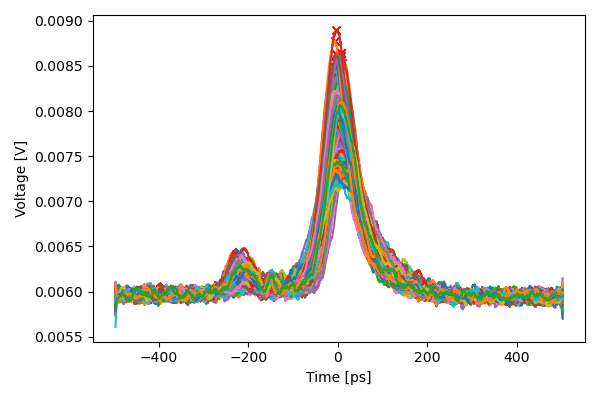

In [10]:
win_len = 100
polyorder = 3

pks_val0, pks_loc0, pks_norm0 = find_peak_delay(ds0, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val1, pks_loc1, pks_norm1 = find_peak_delay(ds1, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val2, pks_loc2, pks_norm2 = find_peak_delay(ds2, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val3, pks_loc3, pks_norm3 = find_peak_delay(ds3, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val4, pks_loc4, pks_norm4 = find_peak_delay(ds4, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val5, pks_loc5, pks_norm5 = find_peak_delay(ds5, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val6, pks_loc6, pks_norm6 = find_peak_delay(ds6, sgolay_winlen=win_len, sgolay_polyord=polyorder)


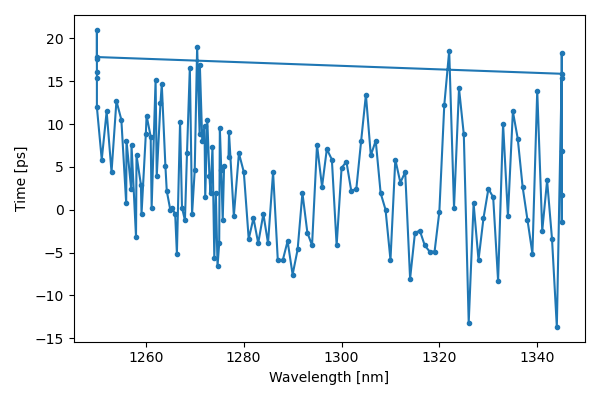

In [11]:
#Plot time delay of peaks vs wavelength
fig,ax1 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax1.plot(ds0["wavelength_set"].to(u.nm), pks_loc0.to(u.ps), marker='.')
# ax1.plot(ds1["wavelength_set"].to(u.nm), pks_loc1.to(u.ps), marker='.')
# ax1.plot(ds2["wavelength_set"].to(u.nm), pks_loc2.to(u.ps), marker='.')
# ax1.plot(ds3["wavelength_set"].to(u.nm), pks_loc3.to(u.ps), marker='.')
# ax1.plot(ds4["wavelength_set"].to(u.nm), pks_loc4.to(u.ps), marker='.')
# ax1.plot(ds5["wavelength_set"].to(u.nm), pks_loc5.to(u.ps), marker='.')
# ax1.plot(ds6["wavelength_set"].to(u.nm), pks_loc6.to(u.ps), marker='.')
ax1.set_xlabel("Wavelength [nm]")
ax1.set_ylabel("Time [ps]")
plt.show()

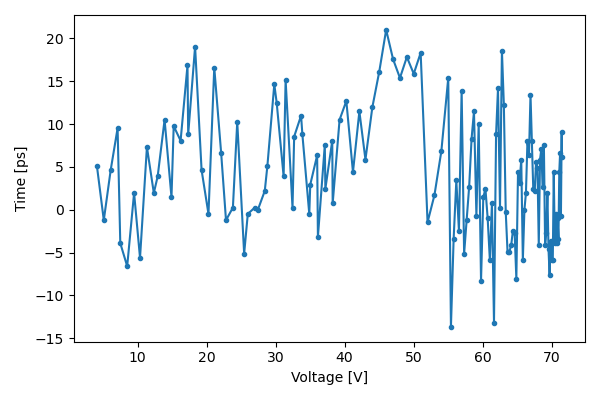

In [12]:
#Plot time delay of peaks vs wavelength
fig,ax1 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax1.plot(ds0["voltage_list"].to(u.V), pks_loc0.to(u.ps), marker='.')
# ax1.plot(ds1["voltage_list"].to(u.V), pks_loc1.to(u.ps), marker='.')
# ax1.plot(ds2["voltage_list"].to(u.V), pks_loc2.to(u.ps), marker='.')
# ax1.plot(ds3["voltage_list"].to(u.V), pks_loc3.to(u.ps), marker='.')
# ax1.plot(ds4["voltage_list"].to(u.V), pks_loc4.to(u.ps), marker='.')
# ax1.plot(ds5["voltage_list"].to(u.V), pks_loc5.to(u.ps), marker='.')
# ax1.plot(ds6["voltage_list"].to(u.V), pks_loc6.to(u.ps), marker='.')
ax1.set_xlabel("Voltage [V]")
ax1.set_ylabel("Time [ps]")
plt.show()

In [ ]:
# ch_VOA.write(2.55*u.V)
# time.sleep(0.5)
# ch_VOA.read()


<Quantity(2.54462567, 'volt')>

In [ ]:
pks_val2, pks_loc2, pks_norm2 = find_peak_delay(ds0, sgolay_winlen=win_len, sgolay_polyord=polyorder)

Text(0, 0.5, 'Amplitude')

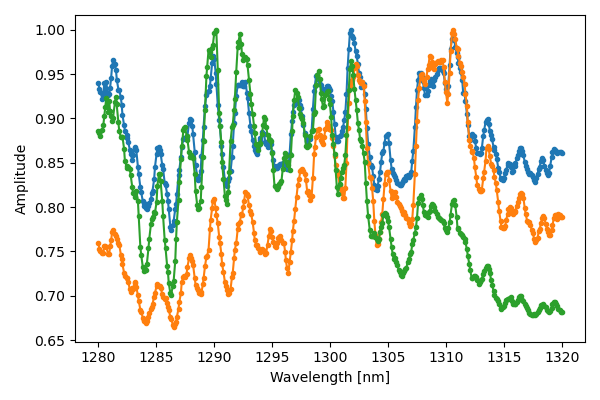

In [ ]:
#Plot normalized pulse amplitude vs wavelength
fig,ax2 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)

ax2.set_xlabel("Wavelength [nm]")
ax2.set_ylabel("Amplitude")

In [11]:
turn_VCSEL_off()

# Save wavvamp_file

ValueError: all input arrays must have the same shape

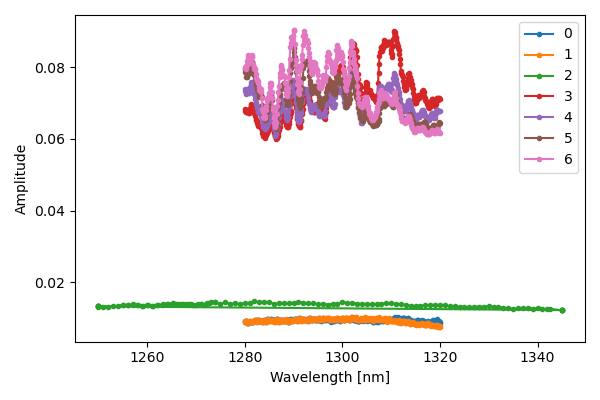

In [ ]:
#Plot unnormalized pulse amplitude vs wavelength
fig,ax2 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax2.plot(ds0["wavelength_set"].to(u.nm), pks_val0, marker='.', label='0')
# ax2.plot(ds1["wavelength_set"].to(u.nm), pks_val1, marker='.', label='1')
# ax2.plot(ds2["wavelength_set"].to(u.nm), pks_val2, marker='.', label='2')
# ax2.plot(ds3["wavelength_set"].to(u.nm), pks_val3, marker='.', label='3')
# ax2.plot(ds4["wavelength_set"].to(u.nm), pks_val4, marker='.', label='4')
# ax2.plot(ds5["wavelength_set"].to(u.nm), pks_val5, marker='.', label='5')
# ax2.plot(ds6["wavelength_set"].to(u.nm), pks_val6, marker='.', label='6')
ax2.set_xlabel("Wavelength [nm]")
ax2.set_ylabel("Amplitude")
plt.legend()
wavelength_set=ds0["wavelength_set"].to(u.nm)
# pks_arr = np.stack((pks_norm0, pks_norm1, pks_norm2, pks_norm3, pks_norm4, pks_norm5, pks_norm6))
pks_arr = np.stack((pks_norm0, pks_norm1, pks_norm2))
pks_av = np.mean(pks_arr, axis=0)
print(pks_av.shape)

fig,ax3 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax3.plot(ds0["wavelength_set"].to(u.nm), pks_arr.T, marker='.')
ax3.plot(ds0["wavelength_set"].to(u.nm), pks_av, marker='.', color='k')

Text(0, 0.5, 'Amplitude')

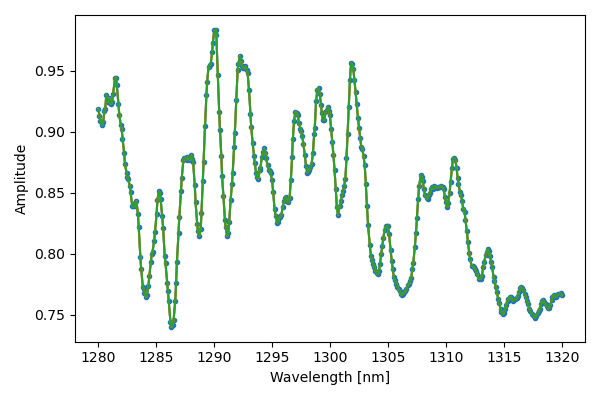

In [22]:


# Interpolate pks_av and create amplitude_scale
wavelength_interp = np.linspace(1280, 1320, 5000)
#reorder by increasing voltage

#load wavvolt_file
a = io.loadmat(wavvolt_file) # Load wavvolt_file
wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
volt_calib = a['volt_interp'][0]*u.V

#interpolate on sorted wavelength
sind = np.argsort(ds0["wavelength_set"].to(u.nm).m)
wavset_sort = ds0["wavelength_set"].to(u.nm).m[sind]
pks_sort = pks_av[sind]
amp_corr = np.interp(wavelength_interp, wavset_sort, pks_sort)


#Reorder to wavvolt_file indices (ordered by increasing voltage)
amplitude_scale = []
for wav in wav_calib.m:
    if wav >= np.min(wavelength_interp) and wav <= np.max(wavelength_interp):
        ind = np.argmin(np.abs(wav - wavelength_interp))
        amplitude_scale.append(amp_corr[ind])
    else: #out of pdfa gain range
        amplitude_scale.append(np.nan)
amplitude_scale = np.array(amplitude_scale)

fig,ax2 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax2.plot(ds0["wavelength_set"].to(u.nm), pks_av, marker='.')
ax2.plot(wavelength_interp, amp_corr)
ax2.plot(wav_calib, amplitude_scale)
ax2.set_xlabel("Wavelength [nm]")
ax2.set_ylabel("Amplitude")


In [23]:
sname = "wavamp_dev1b_delayvolt16P3_2025-12-10-22"
spath = new_path(name=sname, data_dir=calib_dir, extension='h5', timestamp=False)
print("saving data to: ")
print(spath)

dump_hdf5(
    {'wavelength': wav_calib,
     'amplitude_scale': amplitude_scale},
    fpath=spath,
    open_mode='x'
)

saving data to: 
C:\Users\euyehara\experiment_control\calibration_data\VCSEL_calibration\wavamp_dev1b_delayvolt16P3_2025-12-10-22.h5
dumping item: wavelength
dumping item: amplitude_scale


In [102]:
volt=71.6
ramp_VCSEL(volt*u.V)
time.sleep(0.5)
ch_VOA.read()
# HVA_to_wavelength(volt*u.V)

<Quantity(2.17957264, 'volt')>

In [101]:
ch_VOA.write(2.2*u.V)

In [103]:
turn_VCSEL_off()

# Sweep through wavmon

In [4]:
sample_dir = 'BOA_only'
name = 'preview_BOA_300us300uV_5tlia_100reps_0.1nm_10dB_wavvolt_sweepcal'

t_lia = 10*u.ms
τ_settle=5
sens_lia = 1 * u.mV
wav_start = 1250*u.nm#1250*u.nm #1280*u.nm #1249*u.nm
wav_stop = 1342*u.nm #1342*u.nm #1276.8*u.nm

Δwav = 0.1*u.nm 
num_sweep = 1
fixed_wav = 1074.55*u.nm # 1071.4*u.nm#
# ds0 = VCSEL_sweep_spectrum(wav_start, wav_stop, Δwav, num_sweep, t_lia, sens_lia, fixed_wav, sample_dir=sample_dir, name=name, delayvolt_file=delayvolt_file)

ds0 = VCSEL_sweep_spectrum(wav_start, wav_stop, Δwav, num_sweep, t_lia, sens_lia, fixed_wav, sample_dir=sample_dir, name=name, τ_settle=τ_settle)


saving data to: 
C:\Users\euyehara\OneDrive\Documents\data\srs_microscope\Sample_BOA_only_2025-12-12-14-10-47\Spectra_preview_BOA_300us300uV_5tlia_100reps_0.1nm_10dB_wavvolt_sweepcal_2025-12-12-15-27-56.h5
Wavelength out of range: 1250.00 nanometer
Wavelength out of range: 1273.70 nanometer
Wavelength out of range: 1273.80 nanometer
Wavelength out of range: 1273.90 nanometer
Filling wavelength discontinuity
V_MEMS_sweep: 932
V_MEMS_pad_fwd: 932
V_VOA_sweep: 932
num_samp: 932
sweep time: 46.60 second
start time: Fri Dec 12 15:27:58 2025
stop time: Fri Dec 12 15:28:45 2025
dumping item: num_sweep
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
millivolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item:

Calibrating from wavvolt_sweepcal
Calib Peak at 1353.928 / centimeter
Uncal Peak at 1353.928 / centimeter


C:\Users\euyehara\AppData\Local\Temp\ipykernel_35724\2935252655.py:327: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


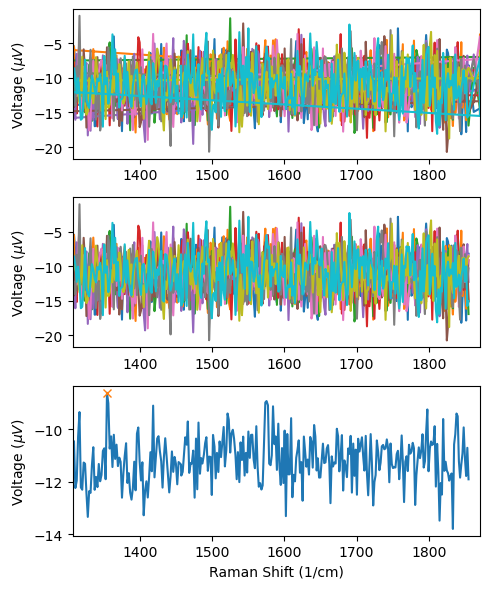

In [27]:
fig = plot_daq_sweepSpectra(ds0, wavvolt=wavvolt_file, wavamp_file=None)

In [30]:
ramp_VCSEL(60.8*u.V)

In [9]:
turn_VCSEL_off()

loading file: FFP-I_peaks
importing peaks...
100


C:\Users\euyehara\AppData\Local\Temp\ipykernel_35724\2935252655.py:146: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", num_reps)


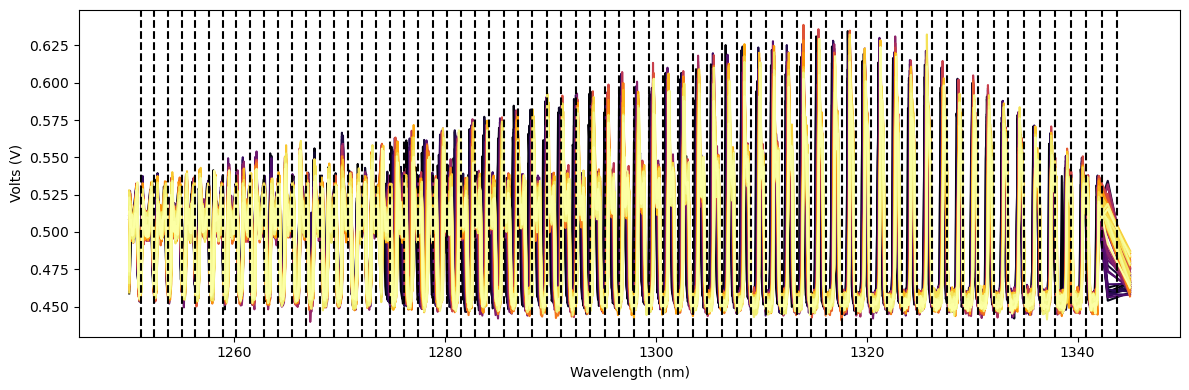

In [34]:
fig, ax = plot_daqsweep_wavmon(ds0, ds_type='sweep', figsize=(12,4), num_reps=None, peaks_rep=-2)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
plt.show()

loading file: FFP-I_peaks
importing peaks...
100


C:\Users\euyehara\AppData\Local\Temp\ipykernel_69692\3582201719.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", num_reps)


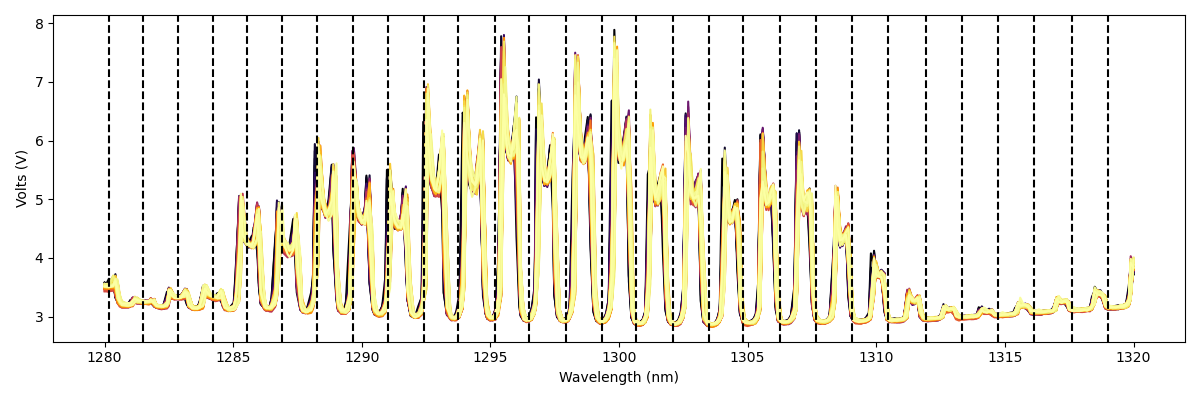

In [107]:
fig, ax = plot_daqsweep_wavmon(ds0, ds_type='sweep', figsize=(12,4), num_reps=100, peaks_rep=-2)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
plt.show()

loading file: FFP-I_peaks
importing peaks...
100


C:\Users\euyehara\AppData\Local\Temp\ipykernel_69692\3481243868.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", num_reps)


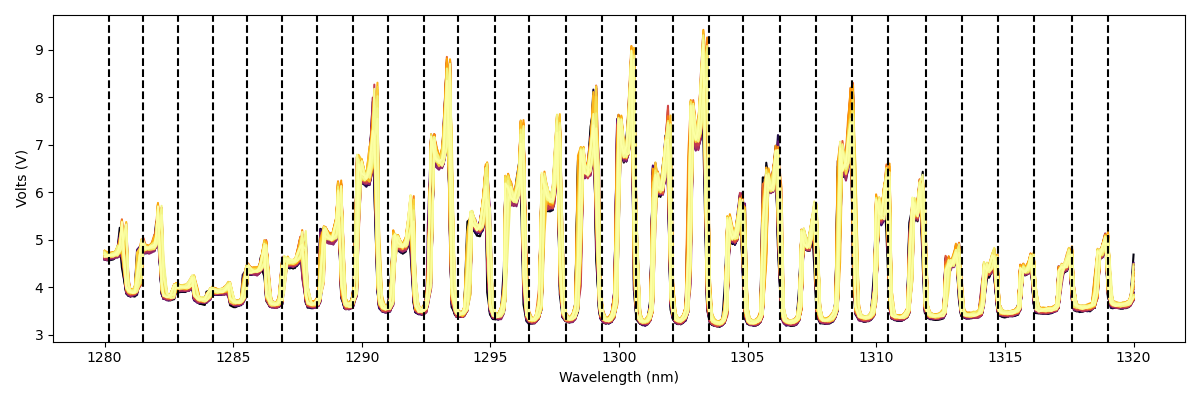

In [140]:
fig, ax = plot_daqsweep_wavmon(ds0, ds_type='sweep', figsize=(12,4), num_reps=100, peaks_rep=-2)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
plt.show()

loading file: FFP-I_peaks
importing peaks...
100


C:\Users\euyehara\AppData\Local\Temp\ipykernel_69692\3481243868.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", num_reps)


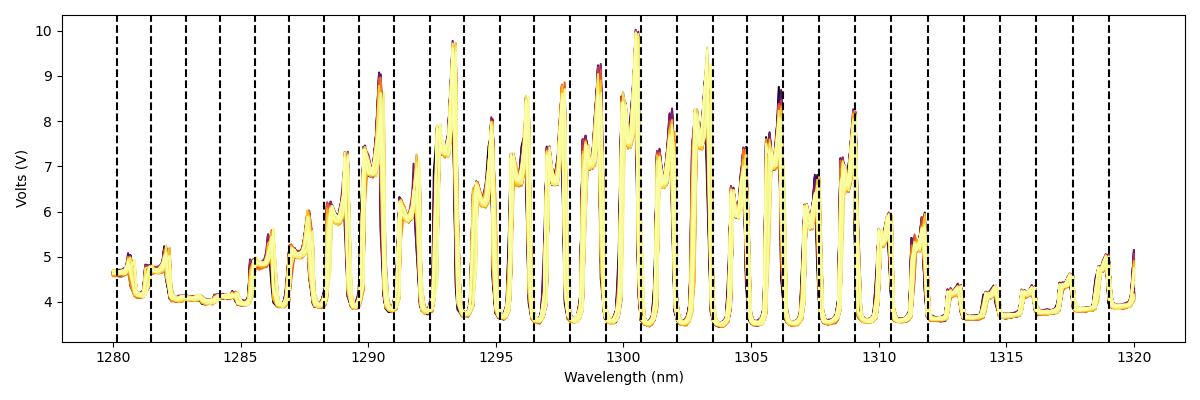

In [143]:
fig, ax = plot_daqsweep_wavmon(ds0, ds_type='sweep', figsize=(12,4), num_reps=100, peaks_rep=-2)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
plt.show()

loading file: FFP-I_peaks
importing peaks...
100


C:\Users\euyehara\AppData\Local\Temp\ipykernel_69692\3481243868.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", num_reps)


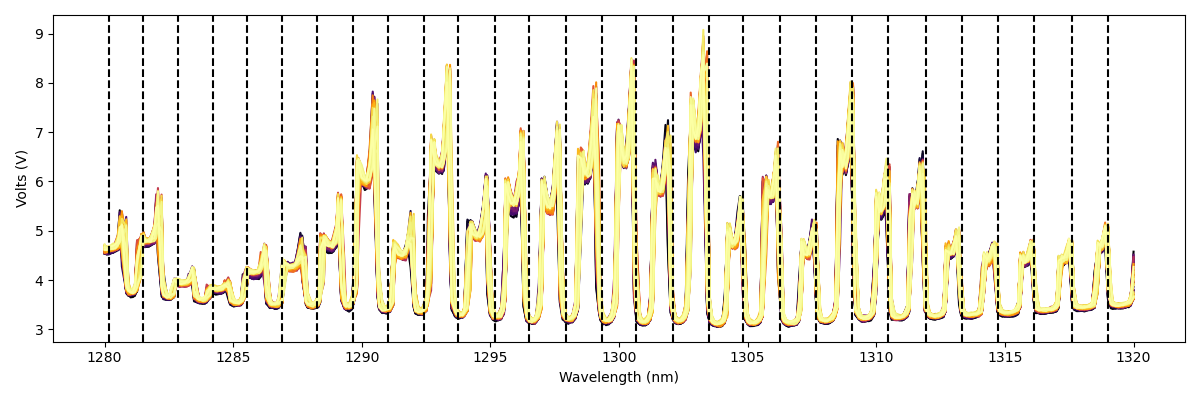

In [146]:
fig, ax = plot_daqsweep_wavmon(ds0, ds_type='sweep', figsize=(12,4), num_reps=100, peaks_rep=-2)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
plt.show()

# Create amplitude calibration curve from wavmon data

loading file: Spectra_testSweep_100us_5tlia_100reps_0.1nm_50dB_micOut_1310_24FinmW_2025-12-09-21-04-11.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing Vsrs_θ...
importing Vsrs_θ_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr t_lia...
microsecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
loading file: FFP-I_peaks
importing peaks...


C:\Users\euyehara\AppData\Local\Temp\ipykernel_10576\818308604.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", num_reps)


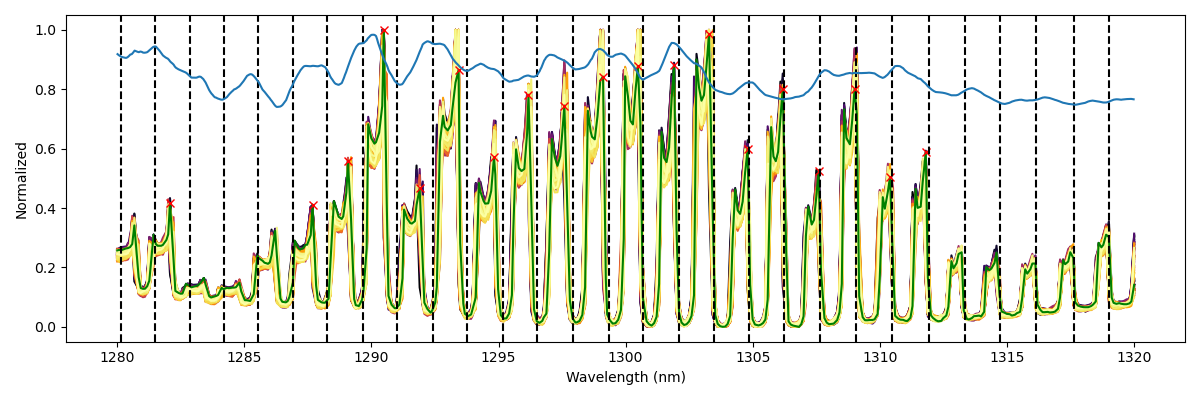

In [37]:


data_dir = os.path.join(home_dir,"OneDrive","Documents","data","srs_microscope")
dir_name = "Sample_test_PDFA_hole_2025-12-07-16-26-03"
fname = "Spectra_testSweep_100us_5tlia_100reps_0.1nm_50dB_micOut_1310_24FinmW_2025-12-09-21-04-11.h5"

fpath = os.path.join(data_dir, dir_name)
ds = load_data_from_file(fpath, fname)
fig, ax = plot_daqsweep_wavmon(ds, ds_type='sweep', figsize=(12,4), num_reps=None, peaks_rep=None)
# ax.plot(wavelength_interp, amp_corr)
ax.plot(wav_calib, amplitude_scale)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
plt.show()

In [21]:
turn_VCSEL_off()

# Collect wavvolt_HVcalib

In [ ]:
sample_dir = "GSdev1b_wavvolt1_712-13-25"
name = "GSdev1b_BOA700mA_0-71.6V"

init_voltage = 0*u.V  # [V]
end_voltage = 2*u.V
# end_voltage = 69*u.V # [V]
increment = 1*u.V  # Voltage increment
voltage_list = np.arange(init_voltage.m, end_voltage.m+increment.m, increment.m)* u.V

#Remove if wavvolt changes!
# voltage_list = np.append(voltage_list.m, np.array([70, 70.5, 71, 71.3, 71.6]))*u.V
print(voltage_list)

osa_settings = {
    "rbw": 0.1*u.nm,
    "ref_level": -17*u.dimensionless,
    "wav_start": 1230*u.nm,
    "wav_stop": 1360*u.nm
}
num_avg=5

# ramp_VCSEL(1*u.V) #turn on
ds=generate_wavvolt(voltage_list, osa_settings, num_avg, sample_dir=sample_dir, name=name)

[0 1 2] volt
saving data to: 
C:\Users\euyehara\experiment_control\calibration_data\VCSEL_calibration\Sample_GSdev1b_wavvolt16_12-13-25_2025-12-13-20-04-18\wavvoltdata_GSdev1b_BOA700mA_0-71.6V_2025-12-13-20-27-02.h5
Opening connnection to Yokogawa AQ6375 OSA
Connected to: YOKOGAWAlAQ6375,91H319783,01.01
Sweeping...
Transferring data...
VOA Voltage set: 2.12 volt
VCSEL Voltage set: 0.0000 V...
Voltage measured: -0.0249 V
Sweeping...
Transferring data...
VOA Voltage set: 2.1238193257476268 volt
VCSEL Voltage set: 1.0000 V...
Voltage measured: 0.9833 V
Sweeping...
Transferring data...
VOA Voltage set: 2.124159100996836 volt
VCSEL Voltage set: 2.0000 V...
Voltage measured: 2.0044 V
Sweeping...
Transferring data...
(3, 6501)
Finished voltage sweep
-----------------------------
dumping item: rbw
non-array, non-list item with units:
nanometer
dumping item: ref_level
non-array, non-list item with units:
dimensionless
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumpin

loading file: wavvoltdata_Sample_GSdev1b_wavvolt17_12-13-25_2025.h5
importing meas_volt_list...
importing meas_wavmon_list...
importing pk_wl_list...
importing spectrum_array...
importing voltage_list...
importing wavelength...
importing attr num_avg...
importing attr rbw...
nanometer
importing attr rbw_units...
importing attr ref_level...
dimensionless
importing attr ref_level_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...


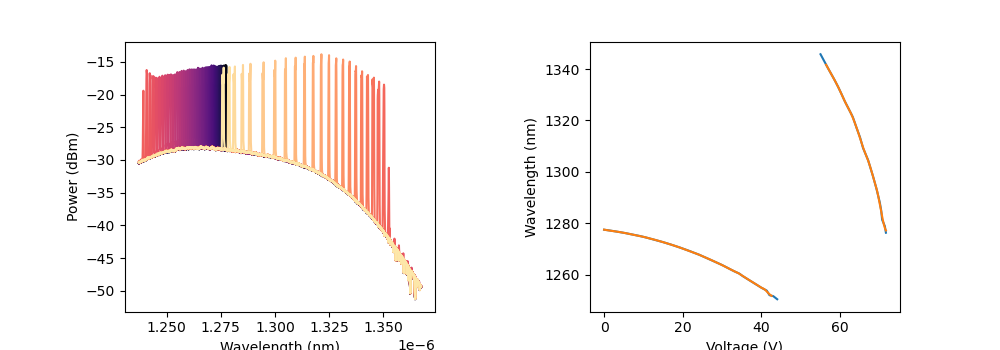

In [45]:
fname = "wavvoltdata_Sample_GSdev1b_wavvolt17_12-13-25_2025.h5"
sample_dir = calib_dir
dir_name ="Sample_GSdev1b_wavvolt17_12-13-25_2025-12-13-20-04-18"

# name="GSdev1b_delayvolt17_BOA700mA"
name = None
# volt_stop=None#88.6*u.V
invalid_volt = (44, 55)*u.V
smooth_param=200
fpath = os.path.join(sample_dir, dir_name)
ds = load_data_from_file(fpath, fname)

%matplotlib widget
save_wavvolt(ds, invalid_volt=invalid_volt, smooth_param=smooth_param, name=None,sample_dir=None)
# save_wavvolt(ds, invalid_volt=None, smooth_param=smooth_param, name=name,sample_dir=sample_dir)

In [37]:
turn_VCSEL_off()